# PCA (freq) + Z-score env — hybrid OR model

**Kaggle-score** (baseline freq-only 0.897 / 0.887)

- Freq channels 41–46: PCA reconstruction error (tail-fit, same as nb11c)
- Env channels 14/21/29: rolling-min envelope residual → zscore (same as ek_baseline_zscore)
  - normalise by nominal-train std  
  - normalise by p99 of |score| on train  
  - grid-search k (top-k channels mean) on val  
- OR combination with independent thresholds

Set `FREQ_NAMES = []` to test env-only in isolation.

In [ ]:
# cell for Colab 
# %%script true
from google.colab import drive
drive.mount('/content/drive')

#%cd drive/MyDrive/Colab Notebooks/sentinel
#!pip install -e .
!pip install numpy pandas pyarrow scikit-learn matplotlib seaborn scipy -q

import sys
sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/sentinel/src")

In [6]:
import sys, time, pickle
from pathlib import Path
#PROJECT_ROOT = Path('..').resolve()
PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/sentinel').resolve() # for Colab only
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.ml_logic.viz        import plot_timeline, plot_event_analysis

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR   = PROCESSED_DIR / 'kaggle'
SUBS_DIR     = PROJECT_ROOT / 'kaggle' / 'submissions'
SUBS_DIR.mkdir(parents=True, exist_ok=True)
FIT_SIZE     = 50_000

# Envelope residual params
ENV_WINDOW    = 200
ENV_MA_WINDOW = 5_000
ENV_REF_PCT   = 99       # percentile for ref_per_ch normalisation

def top_p_mean(arr2d, p):
    """Mean of the top-p fraction of columns by absolute value, per row."""
    n_top = max(1, int(arr2d.shape[1] * p))
    top   = np.partition(arr2d, -n_top, axis=1)[:, -n_top:]
    return top.mean(axis=1)

print(f'KAGGLE_DIR   : {KAGGLE_DIR}')
print(f'WINDOW_SIZE  : {WINDOW_SIZE}   FIT_SIZE: {FIT_SIZE:,}')
print(f'ENV_WINDOW   : {ENV_WINDOW}    ENV_MA_WINDOW: {ENV_MA_WINDOW:,}')

KAGGLE_DIR   : /content/drive/MyDrive/Colab Notebooks/sentinel/data/processed/kaggle
WINDOW_SIZE  : 100   FIT_SIZE: 50,000
ENV_WINDOW   : 200    ENV_MA_WINDOW: 5,000


In [ ]:
# ── Freq channels: raw scaled (PCA) ───────────────────────────────────────────
FREQ_NAMES = [f'channel_{i}' for i in range(41, 47)]   # set [] for env-only
# FREQ_NAMES = []

# ── Env channels: envelope residual (zscore) ──────────────────────────────────
ENV_NAMES  = ['channel_14', 'channel_21', 'channel_29']
# ENV_NAMES = []

_TARGET_CH = pd.read_csv(PROJECT_ROOT / 'data/raw/target_channels.csv')['target_channels'].tolist()
missing    = [c for c in FREQ_NAMES + ENV_NAMES if c not in _TARGET_CH]
assert not missing, f'Missing channels: {missing}'

FREQ_IDX   = np.array([_TARGET_CH.index(n) for n in FREQ_NAMES], dtype=int)
ENV_IDX    = np.array([_TARGET_CH.index(n) for n in ENV_NAMES],  dtype=int)
CH_NAMES   = FREQ_NAMES + ENV_NAMES
CH_INDICES = np.concatenate([FREQ_IDX, ENV_IDX])
assert len(CH_NAMES) > 0, 'At least one group must be non-empty'

print(f'FREQ channels : {FREQ_NAMES or "(none)"}')
print(f'ENV  channels : {ENV_NAMES  or "(none)"}')

FREQ channels : ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
ENV  channels : ['channel_14', 'channel_21', 'channel_29']


In [8]:
DATA_SOURCE = 'kaggle'

y_train_full      = np.load(KAGGLE_DIR / 'y_train_full.npy')
train_scaled_full = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
test_scaled_full  = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids          = np.load(KAGGLE_DIR / 'test_ids.npy')
y_train_row       = np.load(KAGGLE_DIR / 'y_train_row.npy')

TRAIN_END, VAL_END = 10_700_000, 12_700_000
nominal_mask       = (y_train_full == 0)

# ── Freq channels: raw RobustScaler-normalised ────────────────────────────────
train_freq = np.ascontiguousarray(train_scaled_full[:, FREQ_IDX], dtype=np.float32)
test_freq  = test_scaled_full[:, FREQ_IDX].astype(np.float32)

# ── Env channels: envr = rolling_min(200) − centred_MA(5000) ─────────────────
def _envr_cols(arr2d, env_w, ma_w):
    out = np.empty_like(arr2d, dtype=np.float32)
    for j in range(arr2d.shape[1]):
        s   = pd.Series(arr2d[:, j])
        env = s.rolling(window=env_w, min_periods=1).min()
        ma  = env.rolling(window=ma_w, min_periods=1, center=True).mean()
        out[:, j] = (env - ma).values.astype(np.float32)
    return out

if len(ENV_IDX):
    print('Computing env residuals for train …')
    t0 = time.time()
    train_envr = _envr_cols(
        np.ascontiguousarray(train_scaled_full[:, ENV_IDX], dtype=np.float32),
        ENV_WINDOW, ENV_MA_WINDOW)
    print(f'  done in {time.time()-t0:.1f}s')

    print('Computing env residuals for test …')
    test_envr = _envr_cols(test_scaled_full[:, ENV_IDX].astype(np.float32),
                           ENV_WINDOW, ENV_MA_WINDOW)

    # Step 1: normalise by nominal-train std (same as ek_11c)
    _nom_mask_row = y_train_row[:TRAIN_END] == 0
    _envr_std = np.maximum(
        train_envr[:TRAIN_END][_nom_mask_row].std(axis=0, keepdims=True), 1e-6)
    train_envr = (train_envr / _envr_std).astype(np.float32)
    test_envr  = (test_envr  / _envr_std).astype(np.float32)

    # Step 2: ref_per_ch = p99 of |z_raw| on training period (same as ek_baseline_zscore)
    ref_per_ch_env = np.maximum(
        np.percentile(np.abs(train_envr[:TRAIN_END]), ENV_REF_PCT, axis=0), 1e-8
    ).astype(np.float32)
    print(f'ref_per_ch_env (p{ENV_REF_PCT}): {ref_per_ch_env.round(3).tolist()}')
else:
    train_envr = np.empty((train_scaled_full.shape[0], 0), dtype=np.float32)
    test_envr  = np.empty((test_scaled_full.shape[0],  0), dtype=np.float32)
    ref_per_ch_env = np.empty(0, dtype=np.float32)

# ── Stack freq + envr ─────────────────────────────────────────────────────────
train_scaled = np.concatenate([train_freq, train_envr], axis=1)
test_scaled  = np.concatenate([test_freq,  test_envr],  axis=1)
del train_freq, train_envr, test_freq, test_envr

X_val  = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END], dtype=np.float32)
y_val  = y_train_row[TRAIN_END:VAL_END]
X_test = np.ascontiguousarray(train_scaled[VAL_END:],          dtype=np.float32)
y_test = y_train_row[VAL_END:]

print(f'train_scaled : {train_scaled.shape}')
print(f'X_val        : {X_val.shape}   anom rows: {int(y_val.sum()):>8,}')
print(f'X_test       : {X_test.shape}   anom rows: {int(y_test.sum()):>8,}')

Computing env residuals for train …
  done in 13.1s
Computing env residuals for test …
ref_per_ch_env (p99): [6.769000053405762, 7.142000198364258, 5.263999938964844]
train_scaled : (14728321, 9)
X_val        : (2000000, 9)   anom rows:  215,798
X_test       : (2028321, 9)   anom rows:  214,935


In [9]:
n_freq = len(FREQ_IDX)
n_env  = len(ENV_IDX)

# Shared tail-fit window indices
win_end_row = (np.arange(len(y_train_full)) + 1) * WINDOW_SIZE
eligible    = nominal_mask & (win_end_row <= TRAIN_END)
fit_idx     = np.flatnonzero(eligible)[-FIT_SIZE:]
_row_idx    = (fit_idx[:, None] * WINDOW_SIZE + np.arange(WINDOW_SIZE)[None, :]).ravel()

# ── Freq PCA only (env uses zscore — no PCA needed) ──────────────────────────
if n_freq:
    X_fit_freq = train_scaled[_row_idx, :n_freq].reshape(len(fit_idx), -1).astype(np.float32)
    t0 = time.time()
    pca_freq = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_fit_freq)
    print(f'FREQ PCA  k={pca_freq.n_components_}  '
          f'EV={pca_freq.explained_variance_ratio_.sum():.4f}  '
          f'({X_fit_freq.shape[1]:,} features, {time.time()-t0:.1f}s)')
    del X_fit_freq
else:
    pca_freq = None
    print('FREQ channels disabled — pca_freq = None')

del _row_idx

FREQ PCA  k=183  EV=0.9502  (600 features, 0.5s)


In [10]:
t0 = time.time()

# ── Freq: PCA reconstruction error (row-level) ────────────────────────────────
val_scores_freq  = (score_windows(pca_freq, X_val[:, :n_freq])
                    if pca_freq is not None
                    else np.zeros(len(y_val), dtype=np.float32))
test_scores_freq = (score_windows(pca_freq, X_test[:, :n_freq])
                    if pca_freq is not None
                    else np.zeros(len(y_test), dtype=np.float32))

# ── Env: per-channel absolute zscore (envr / std / ref_per_ch) ────────────────
# Shape: (n_rows, n_env) — absolute values so spikes in both directions are caught
if n_env:
    z_val_env  = np.abs(X_val[:,  n_freq:] / ref_per_ch_env).astype(np.float32)
    z_test_env = np.abs(X_test[:, n_freq:] / ref_per_ch_env).astype(np.float32)
else:
    z_val_env  = np.empty((len(y_val),  0), dtype=np.float32)
    z_test_env = np.empty((len(y_test), 0), dtype=np.float32)

print(f'scoring done in {time.time()-t0:.1f}s')
print(f'val freq : [{val_scores_freq.min():.4f}, {val_scores_freq.max():.4f}]  mean={val_scores_freq.mean():.4f}')
if n_env:
    print(f'val env  : per-ch max={z_val_env.max(axis=0).round(2).tolist()}')

scoring done in 0.7s
val freq : [0.0114, 30.4104]  mean=0.0233
val env  : per-ch max=[8.300000190734863, 4.329999923706055, 7.539999961853027]


In [11]:
# ── Freq: standard threshold tuning ──────────────────────────────────────────
if pca_freq is not None:
    tuned_freq     = tune_threshold(val_scores_freq, y_val, corrected_event_f05, n_sweep=80)
    threshold_freq = float(tuned_freq['threshold'])
    print(f'FREQ  thr={threshold_freq:.6f}   val F0.5={tuned_freq["score"]:.4f}')
else:
    threshold_freq = np.inf

# ── Env: grid search over k (1..n_env) then tune threshold ───────────────────
if n_env:
    print(f'\n── ENV k-grid search ({n_env} channels) ──────────────────')
    print(f'  {"k":>3}  {"val F0.5":>9}  {"thr":>10}')
    best_env_f05, best_p_env, best_thr_env = -1.0, 1.0, None
    for k in range(1, n_env + 1):
        p   = k / n_env
        sc  = top_p_mean(z_val_env, p=p)
        res = tune_threshold(sc, y_val, corrected_event_f05, n_sweep=80)
        print(f'  {k:>3}  {res["score"]:>9.4f}  {res["threshold"]:>10.4f}')
        if res['score'] > best_env_f05:
            best_env_f05 = res['score']
            best_p_env   = p
            best_thr_env = res['threshold']
    threshold_env = float(best_thr_env)
    k_env = int(round(best_p_env * n_env))
    print(f'\n→ best k={k_env}/{n_env}  thr={threshold_env:.6f}  val F0.5={best_env_f05:.4f}')

    val_scores_env  = top_p_mean(z_val_env,  p=best_p_env)
    test_scores_env = top_p_mean(z_test_env, p=best_p_env)
else:
    threshold_env   = np.inf
    best_p_env      = 1.0
    val_scores_env  = np.zeros(len(y_val),  dtype=np.float32)
    test_scores_env = np.zeros(len(y_test), dtype=np.float32)

# ── OR-combined preview ───────────────────────────────────────────────────────
_y_or = ((val_scores_freq > threshold_freq) |
         (val_scores_env  > threshold_env )).astype(np.int8)
print(f'\nOR combined  val corrected_event_f05: '
      f'{corrected_event_f05(y_val, _y_or)["f_score"]:.4f}')

# Unified score for viz (max of normalised, threshold = 1.0)
def _combined(sf, se):
    sf_n = sf / threshold_freq if threshold_freq < np.inf else np.zeros_like(sf)
    se_n = se / threshold_env  if threshold_env  < np.inf else np.zeros_like(se)
    return np.maximum(sf_n, se_n)

val_scores  = _combined(val_scores_freq, val_scores_env)
test_scores = _combined(test_scores_freq, test_scores_env)
threshold   = 1.0

FREQ  thr=0.028049   val F0.5=0.8534

── ENV k-grid search (3 channels) ──────────────────
    k   val F0.5         thr
    1     0.7816      0.9315
    2     0.7829      1.2370
    3     0.7827      1.0782

→ best k=2/3  thr=1.236991  val F0.5=0.7829

OR combined  val corrected_event_f05: 0.9391


In [12]:
def compute_metrics(scores, y_true, threshold):
    y_pred = (scores > threshold).astype(np.int8)
    ef     = event_f05(y_true, y_pred)
    esa    = corrected_event_f05(y_true, y_pred)
    rw     = row_precision_recall(y_true, y_pred)
    n_ev_total = int(ef['tp_events'] + ef['fn_events'])
    n_ev_hit   = int(ef['tp_events'])
    return {
        'ESA F0.5 (Kaggle)' : esa['f_score'],
        'Pr_ew (event prec)': esa['precision'],
        'TNR (row spec)'    : esa['tnr'],
        'event F0.5 (raw)'  : ef['f_score'],
        'event recall'      : ef['recall'],
        'event precision'   : ef['precision'],
        'row precision'     : rw['precision'],
        'row recall'        : rw['recall'],
        'row F1'            : rw['f1'],
        'flag rate'         : float(y_pred.mean()),
        'events hit'        : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit/max(n_ev_total,1):.1%})',
        '_y_pred'           : y_pred,
    }

m_val  = compute_metrics(val_scores,  y_val,  threshold)
m_test = compute_metrics(test_scores, y_test, threshold)

metrics_order = ['ESA F0.5 (Kaggle)', 'Pr_ew (event prec)', 'TNR (row spec)',
                 'event F0.5 (raw)', 'event recall', 'event precision',
                 'row precision', 'row recall', 'row F1', 'flag rate', 'events hit']

def _fmt(v):
    if isinstance(v, str):   return v
    if isinstance(v, float): return f'{v:.4f}' if abs(v) >= 1e-4 else f'{v:.2e}'
    return str(v)

df_m = pd.DataFrame({'Metric': metrics_order,
                     'Val'   : [m_val[k]  for k in metrics_order],
                     'Test'  : [m_test[k] for k in metrics_order]})
df_m['Val']  = df_m['Val'].map(_fmt)
df_m['Test'] = df_m['Test'].map(_fmt)

freq_lbl = ','.join(c.replace('channel_','') for c in FREQ_NAMES) or 'none'
env_lbl  = ','.join(c.replace('channel_','') for c in ENV_NAMES)  or 'none'
print(f'freq=[{freq_lbl}]  env=[{env_lbl}]  '
      f'k_env={k_env if n_env else 0}/{n_env}  '
      f'thr_freq={threshold_freq:.4f}  thr_env={threshold_env:.4f}')
print(df_m.to_string(index=False))

freq=[41,42,43,44,45,46]  env=[14,21,29]  k_env=2/3  thr_freq=0.0280  thr_env=1.2370
            Metric           Val          Test
 ESA F0.5 (Kaggle)        0.9391        0.8216
Pr_ew (event prec)        0.9939        0.9303
    TNR (row spec)        0.9939        0.9967
  event F0.5 (raw)        0.9434        0.8235
      event recall        0.7692        0.5600
   event precision        1.0000        0.9333
     row precision        0.5386        0.7711
        row recall        0.0587        0.0937
            row F1        0.1059        0.1672
         flag rate        0.0118        0.0129
        events hit 20/26 (76.9%) 14/25 (56.0%)


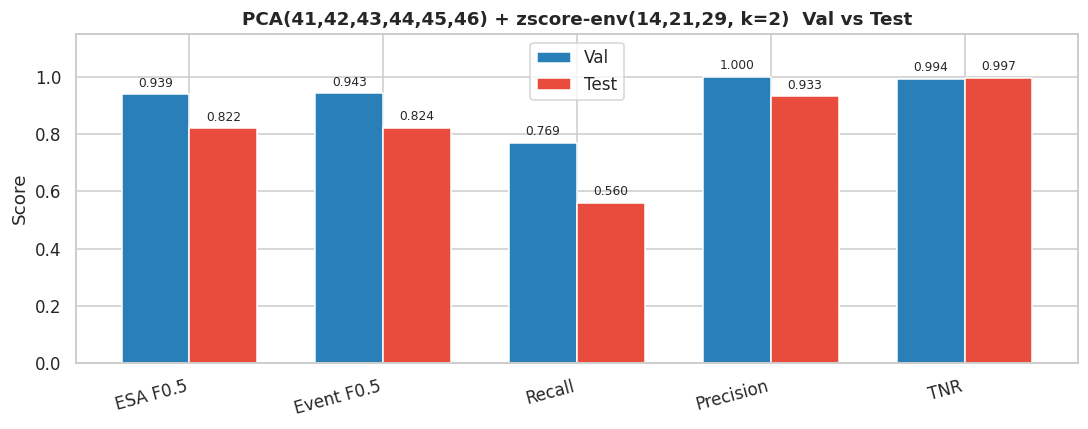

In [13]:
LABEL_TO_KEY = {
    'ESA F0.5'  : 'ESA F0.5 (Kaggle)',
    'Event F0.5': 'event F0.5 (raw)',
    'Recall'    : 'event recall',
    'Precision' : 'event precision',
    'TNR'       : 'TNR (row spec)',
}
labels = list(LABEL_TO_KEY)
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar(x - w/2, [m_val[LABEL_TO_KEY[l]]  for l in labels], w, label='Val',  color=NOMINAL_COLOR)
b2 = ax.bar(x + w/2, [m_test[LABEL_TO_KEY[l]] for l in labels], w, label='Test', color=ANOMALY_COLOR)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.legend()
ax.set_title(f'PCA({freq_lbl}) + zscore-env({env_lbl}, k={k_env if n_env else 0})  Val vs Test',
             fontweight='bold')
fig.tight_layout(); plt.show()

In [14]:
X_kaggle = test_scaled.astype(np.float32, copy=False)

kf = (score_windows(pca_freq, X_kaggle[:, :n_freq])
      if pca_freq is not None else np.zeros(len(X_kaggle), dtype=np.float32))

if n_env:
    z_ke   = np.abs(X_kaggle[:, n_freq:] / ref_per_ch_env).astype(np.float32)
    ke     = top_p_mean(z_ke, p=best_p_env)
else:
    ke     = np.zeros(len(X_kaggle), dtype=np.float32)

y_kaggle = ((kf > threshold_freq) | (ke > threshold_env)).astype(np.uint8)

print(f'positive rate : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')

submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_kaggle})
sample_sub = pd.read_parquet(PROJECT_ROOT / 'data/raw/sample_submission.parquet')
assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch'

ts   = time.strftime('%Y%m%d_%H%M%S')
tag  = f'pca{freq_lbl}_zsenv{env_lbl}_k{k_env if n_env else 0}'
out  = SUBS_DIR / f'pca_zsenv_{tag}_{ts}.parquet'
submission.to_parquet(out, index=False)
print(f'Saved → {out}')

positive rate : 1.5226%  (7,937 / 521,280)
Saved → /content/drive/MyDrive/Colab Notebooks/sentinel/kaggle/submissions/pca_zsenv_pca41,42,43,44,45,46_zsenv14,21,29_k2_20260428_121241.parquet
